# Cluster 6

In [1]:
# ============================================
# 0) Shared imports
# ============================================
import warnings
from dataclasses import dataclass
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "train_hourly_preprocessed.parquet").exists():
    for candidate in PROJECT_ROOT.parents:
        if (candidate / "data" / "train_hourly_preprocessed.parquet").exists():
            PROJECT_ROOT = candidate
            break

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train_hourly_preprocessed.parquet"
TEST_PATH = DATA_DIR / "test_hourly_preprocessed.parquet"
DIRECT_OUTPUT_DIR = PROJECT_ROOT / "cluster6/artifacts/eval/direct_trend"
DATA_OUTPUT_DIR = PROJECT_ROOT / "cluster6/artifacts/data"
OUTPUT_DIR = PROJECT_ROOT / "cluster6/artifacts/plots/visualization"
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_METER_ID = "MT_362"
TIMESTAMP_COLUMN = "timestamp"
N_PERIODS = 4
MAPE_EPSILON = 1e-6


def read_parquet_compat(path: Path) -> pd.DataFrame:
    for engine in ("fastparquet", "pyarrow"):
        try:
            return pd.read_parquet(path, engine=engine)
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not read {path}: {last_error}")


def ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        out[TIMESTAMP_COLUMN] = pd.to_datetime(out[TIMESTAMP_COLUMN])
        out = out.set_index(TIMESTAMP_COLUMN)
    out.index = pd.to_datetime(out.index)
    return out.sort_index()


def epsilon_ape_pct(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> np.ndarray:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.clip(np.abs(y_true), epsilon, None)
    return np.abs(y_true - y_pred) / denom * 100.0


def ape_pct(y_true, y_pred, eps=MAPE_EPSILON) -> np.ndarray:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    out = np.full(len(y_true), np.nan, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > eps)
    out[mask] = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100.0
    return out


def mape_0_100(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> float:
    values = epsilon_ape_pct(y_true, y_pred, epsilon)
    mask = np.isfinite(values)
    if mask.sum() == 0:
        return np.nan
    return float(np.clip(values[mask], 0.0, 100.0).mean())


def epsilon_mape_pct(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> float:
    values = epsilon_ape_pct(y_true, y_pred, epsilon)
    mask = np.isfinite(values)
    if mask.sum() == 0:
        return np.nan
    return float(values[mask].mean())


def wmape_0_100(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    denom = max(float(np.abs(y_true[mask]).sum()), float(epsilon))
    return float(100.0 * np.abs(y_true[mask] - y_pred[mask]).sum() / denom)


def evaluate_tft_style_metrics(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> dict:
    y_true_arr = np.asarray(y_true, dtype=float)
    return {
        "MAPE_0_100": mape_0_100(y_true, y_pred, epsilon),
        "EPSILON_MAPE_PCT": epsilon_mape_pct(y_true, y_pred, epsilon),
        "WMAPE_0_100": wmape_0_100(y_true, y_pred, epsilon),
        "n_obs": int(len(y_true_arr)),
        "n_positive": int(np.isfinite(y_true_arr).sum() and (np.abs(y_true_arr) > epsilon).sum()),
    }


def period_metric_pivot(metrics_by_period: pd.DataFrame, metric_col: str):
    pivot = metrics_by_period.pivot(index="method", columns="period", values=metric_col)

    def _period_key(label):
        label = str(label)
        if label.startswith("P") and label[1:].isdigit():
            return (0, int(label[1:]))
        return (1, label)

    return pivot.reindex(sorted(pivot.columns, key=_period_key), axis=1)


def add_period_column(df: pd.DataFrame, n_periods: int = 3) -> pd.DataFrame:
    out = df.copy()
    out["test_month"] = pd.to_datetime(out["timestamp"]).dt.to_period("M").astype(str)
    ordered_months = sorted(out["test_month"].dropna().unique().tolist())
    if len(ordered_months) == 3:
        period_map = {month: f"P{index}" for index, month in enumerate(ordered_months, start=1)}
        out["period"] = out["test_month"].map(period_map)
        return out.drop(columns=["test_month"])

    unique_ts = np.array(sorted(out["timestamp"].dropna().unique()))
    chunks = np.array_split(unique_ts, n_periods)
    mapper = {}
    for i, chunk in enumerate(chunks, start=1):
        for ts in chunk:
            mapper[pd.Timestamp(ts)] = f"P{i}"
    out["period"] = out["timestamp"].map(mapper)
    return out.drop(columns=["test_month"])


def recursive_lag_forecast(history: pd.Series, future_index: pd.DatetimeIndex, lag: int) -> pd.Series:
    values = list(history.astype(float).values)
    preds = []
    for _ in future_index:
        pred = values[-lag] if len(values) >= lag else values[-1]
        pred = max(0.0, float(pred))
        preds.append(pred)
        values.append(pred)
    return pd.Series(preds, index=future_index, name="pred_seasonal_naive")


def method_display(method: str) -> str:
    return {
        "seasonal_naive": "Seasonal Naive 24-Hour Baseline",
        "selected_model": "Selected Direct Model Forecast",
        "direct_xgboost": "Direct XGBoost Forecast",
        "direct_lightgbm": "Direct LightGBM Forecast",
        "prophet": "Prophet Forecast",
        "naive": "Naive Forecast",
    }.get(method, method)


def compute_metric_tables(pred_df: pd.DataFrame, method_cols: dict) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    overall_rows = []
    period_rows = []
    ape_rows = []

    for method, col in method_cols.items():
        overall_rows.append({
            "method": method,
            "method_display": method_display(method),
            **evaluate_tft_style_metrics(pred_df["y"], pred_df[col]),
            "legacy_MAPE_PCT": float(np.nanmean(ape_pct(pred_df["y"], pred_df[col]))),
            "pred_nonzero_rate": float((pred_df[col] > 0).mean()),
            "actual_nonzero_rate": float((pred_df["y"] > 0).mean()),
        })
        for period, sub in pred_df.groupby("period", sort=True):
            period_rows.append({
                "method": method_display(method),
                "period": period,
                **evaluate_tft_style_metrics(sub["y"], sub[col]),
            })
        epsilon_apes = epsilon_ape_pct(pred_df["y"], pred_df[col])
        ape_rows.append(pd.DataFrame({
            "timestamp": pred_df["timestamp"],
            "period": pred_df["period"],
            "method": method,
            "method_display": method_display(method),
            "APE_PCT": ape_pct(pred_df["y"], pred_df[col]),
            "EPSILON_APE_PCT": epsilon_apes,
            "APE_PCT_0_100": np.clip(epsilon_apes, 0.0, 100.0),
        }))

    return pd.DataFrame(overall_rows), pd.DataFrame(period_rows), pd.concat(ape_rows, ignore_index=True)


@dataclass
class C6Artifact:
    prediction_output_path: str
    pred_df: pd.DataFrame
    metrics_overall: pd.DataFrame
    metrics_by_period: pd.DataFrame
    ape_box_df: pd.DataFrame
    tuning_best_config: dict
    metadata: dict


def plot_cluster_aggregate_lines(pred_df, method_cols, cluster_label, actual_name, target_label, output_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(pred_df["timestamp"], pred_df["y"], label=actual_name, linewidth=2.0, color="#1f77b4")
    ax.plot(pred_df["timestamp"], pred_df[method_cols["baseline"]], label=method_display("seasonal_naive"), linewidth=1.6, color="#ff7f0e")
    ax.plot(pred_df["timestamp"], pred_df[method_cols["model"]], label=method_display("selected_model"), linewidth=1.6, color="#2ca02c")

    for role, color in [("baseline", "#ff7f0e"), ("model", "#2ca02c")]:
        col = method_cols[role]
        resid = pred_df["y"] - pred_df[col]
        sigma = resid.expanding(min_periods=24).std().shift(1).fillna(resid.std(ddof=0))
        low = np.clip(pred_df[col] - 1.96 * sigma, 0.0, None)
        high = pred_df[col] + 1.96 * sigma
        ax.fill_between(pred_df["timestamp"], low, high, color=color, alpha=0.12)

    ax.set_title(f"{cluster_label}: Actual vs Forecast with Residual-Based 95% Intervals")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel(target_label)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / "c6_01_cluster_aggregate_lines.svg", format="svg", bbox_inches="tight")
    plt.show()


def plot_rolling_mape_trend(pred_df, method_cols, cluster_label, window, output_dir):
    fig, ax = plt.subplots(figsize=(14, 3.8))
    for role, col in method_cols.items():
        ape = pd.Series(ape_pct(pred_df["y"], pred_df[col]), index=pred_df.index)
        rolling = ape.rolling(window, min_periods=window).mean()
        label = method_display("seasonal_naive" if role == "baseline" else "selected_model")
        ax.plot(pred_df["timestamp"], rolling, label=label, linewidth=2)
    ax.set_title(f"{cluster_label}: Rolling {window}-Hour MAPE")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Rolling MAPE (%)")
    ax.legend(title="Forecast")
    fig.tight_layout()
    fig.savefig(output_dir / "c6_02_rolling_mape_trend.svg", format="svg", bbox_inches="tight")
    plt.show()


def plot_residual_time_series(pred_df, method_cols, cluster_label, rolling_window, output_dir):
    out = pred_df[["timestamp"]].copy()
    out["baseline_residual"] = pred_df["y"] - pred_df[method_cols["baseline"]]
    out["model_residual"] = pred_df["y"] - pred_df[method_cols["model"]]
    out["baseline_resid_roll_mean"] = out["baseline_residual"].rolling(rolling_window, min_periods=rolling_window).mean()
    out["model_resid_roll_mean"] = out["model_residual"].rolling(rolling_window, min_periods=rolling_window).mean()

    fig, ax = plt.subplots(figsize=(14, 4.2))
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.plot(out["timestamp"], out["baseline_residual"], color="#ff7f0e", alpha=0.30, linewidth=1.0, label="Baseline residual")
    ax.plot(out["timestamp"], out["model_residual"], color="#2ca02c", alpha=0.30, linewidth=1.0, label="Model residual")
    ax.plot(out["timestamp"], out["baseline_resid_roll_mean"], color="#ff7f0e", linewidth=2.0, label=f"Baseline residual {rolling_window}h mean")
    ax.plot(out["timestamp"], out["model_resid_roll_mean"], color="#2ca02c", linewidth=2.0, label=f"Model residual {rolling_window}h mean")
    ax.set_title(f"{cluster_label}: Residual Trend (Actual Minus Forecast)")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Residual")
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    fig.savefig(output_dir / "c6_03_residual_time_series.svg", format="svg", bbox_inches="tight")
    plt.show()
    return out


def plot_actual_vs_predicted_scatter(pred_df, method_cols, cluster_label, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (role, col) in zip(axes, method_cols.items()):
        x = pred_df["y"].values
        y = pred_df[col].values
        lim = float(max(np.nanmax(x), np.nanmax(y)) * 1.05)
        ax.scatter(x, y, alpha=0.45, s=16, color="#1f77b4")
        ax.plot([0, lim], [0, lim], linestyle="--", color="#d62728", linewidth=1.6)
        label = method_display("seasonal_naive" if role == "baseline" else "selected_model")
        ax.set_title(f"{cluster_label}: Actual vs Predicted for {label}")
        ax.set_xlabel("Actual load")
        ax.set_ylabel("Predicted load")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
    fig.tight_layout()
    fig.savefig(output_dir / "c6_04_actual_predicted_scatter.svg", format="svg", bbox_inches="tight")
    plt.show()


def run_cluster_analysis(art, cluster_tag, cluster_label, baseline_col, model_col, baseline_name, model_name, actual_name, target_label, rolling_metric, rolling_window, eps, n_periods, save_svg, output_dir):
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    method_cols = {"baseline": baseline_col, "model": model_col}
    plot_cluster_aggregate_lines(art.pred_df, method_cols, cluster_label, actual_name, target_label, out_dir)
    plot_rolling_mape_trend(art.pred_df, method_cols, cluster_label, rolling_window, out_dir)
    residual_df = plot_residual_time_series(art.pred_df, method_cols, cluster_label, rolling_window, out_dir)
    plot_actual_vs_predicted_scatter(art.pred_df, method_cols, cluster_label, out_dir)

    error_decomposition = pd.DataFrame({
        "method": [baseline_name, model_name],
        "mean_signed_pct_error": [
            float(np.nanmean((art.pred_df["y"] - art.pred_df[baseline_col]) / art.pred_df["y"].replace(0, np.nan) * 100)),
            float(np.nanmean((art.pred_df["y"] - art.pred_df[model_col]) / art.pred_df["y"].replace(0, np.nan) * 100)),
        ],
        "median_ape_pct": [
            float(np.nanmedian(ape_pct(art.pred_df["y"], art.pred_df[baseline_col]))),
            float(np.nanmedian(ape_pct(art.pred_df["y"], art.pred_df[model_col]))),
        ],
    })

    distribution_shift_stats = pd.DataFrame([{
        "actual_mean": float(art.pred_df["y"].mean()),
        "baseline_pred_mean": float(art.pred_df[baseline_col].mean()),
        "model_pred_mean": float(art.pred_df[model_col].mean()),
        "actual_std": float(art.pred_df["y"].std()),
        "baseline_pred_std": float(art.pred_df[baseline_col].std()),
        "model_pred_std": float(art.pred_df[model_col].std()),
    }])

    return {
        "metric_table": art.metrics_overall,
        "metrics_by_period": art.metrics_by_period,
        "error_decomposition": error_decomposition,
        "distribution_shift_stats": distribution_shift_stats,
        "residual_time_series": residual_df,
    }


In [2]:
# ============================================
# 1) Load C6 direct-model predictions and display standardized outputs
# ============================================
train_panel = ensure_datetime_index(read_parquet_compat(TRAIN_PATH))
test_panel = ensure_datetime_index(read_parquet_compat(TEST_PATH))

train_y = train_panel[TARGET_METER_ID].astype(float).rename("load")
test_y = test_panel[TARGET_METER_ID].astype(float).rename("load")
seasonal_lag = 24

final_results_path = DIRECT_OUTPUT_DIR / "final_test_results.parquet"
forecast_detail_path = DIRECT_OUTPUT_DIR / "final_test_forecast_detail.parquet"
if not final_results_path.exists() or not forecast_detail_path.exists():
    raise FileNotFoundError(
        "Run cluster6_direct_lgbm_xgb_prophet_forecasting.ipynb first so final_test_results.parquet "
        "and final_test_forecast_detail.parquet exist."
    )

final_results = pd.read_parquet(final_results_path)
selected_model = str(final_results.loc[0, "selected_model"])
selected_params = final_results.loc[0, "selected_parameters"]

forecast_detail = pd.read_parquet(forecast_detail_path)
forecast_detail["timestamp"] = pd.to_datetime(forecast_detail["timestamp"])
forecast_detail = forecast_detail.sort_values("timestamp")

pred_seasonal = recursive_lag_forecast(train_y, test_y.index, seasonal_lag)
selected_pred = forecast_detail.set_index("timestamp")["prediction"].reindex(test_y.index)
if selected_pred.isna().any():
    missing = int(selected_pred.isna().sum())
    raise ValueError(f"Selected-model forecast is missing {missing} timestamps from the test index.")

pred_df = pd.DataFrame({
    "timestamp": test_y.index,
    "y": test_y.values,
    "pred_seasonal_naive": pred_seasonal.values,
    "pred_selected_model": selected_pred.values,
})
pred_df = add_period_column(pred_df, n_periods=N_PERIODS)

method_cols = {
    "seasonal_naive": "pred_seasonal_naive",
    selected_model: "pred_selected_model",
}
metrics_overall, metrics_by_period, ape_box_df = compute_metric_tables(pred_df, method_cols)

prediction_output_path = DATA_OUTPUT_DIR / "c6_prediction.parquet"
pred_df.to_parquet(prediction_output_path, index=False, engine="pyarrow")

art_c6 = C6Artifact(
    prediction_output_path=str(prediction_output_path),
    pred_df=pred_df,
    metrics_overall=metrics_overall,
    metrics_by_period=metrics_by_period,
    ape_box_df=ape_box_df,
    tuning_best_config={"selected_model": selected_model, "selected_parameters": selected_params},
    metadata={
        "target_meter_id": TARGET_METER_ID,
        "train_range": f"{train_y.index.min()} to {train_y.index.max()}",
        "test_range": f"{test_y.index.min()} to {test_y.index.max()}",
        "seasonal_lag": seasonal_lag,
        "metric": "evaluate_tft style: MAPE_0_100, EPSILON_MAPE_PCT, WMAPE_0_100",
        "mape_epsilon": MAPE_EPSILON,
    },
)

print("C6 prediction file:", art_c6.prediction_output_path)
print("Selected model:", selected_model)
print("\n=== C6 Summary Metrics ===")
display(art_c6.metrics_overall[[
    "method",
    "method_display",
    "MAPE_0_100",
    "EPSILON_MAPE_PCT",
    "WMAPE_0_100",
    "legacy_MAPE_PCT",
    "n_obs",
    "n_positive",
    "pred_nonzero_rate",
    "actual_nonzero_rate",
]])

print("\n=== C6 MAPE_0_100 by Period ===")
display(period_metric_pivot(art_c6.metrics_by_period, "MAPE_0_100"))

print("\n=== C6 Selected Model Parameters ===")
display(pd.DataFrame([art_c6.tuning_best_config]))

print("\n=== C6 Metadata ===")
display(pd.DataFrame([art_c6.metadata]))


C6 prediction file: /Users/qrange77/Desktop/Forecasting/Proj2/Electricity-Load-Prediction/cluster6/artifacts/data/c6_prediction.parquet
Selected model: direct_xgboost

=== C6 Summary Metrics ===


,method,method_display,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,legacy_MAPE_PCT,n_obs,n_positive,pred_nonzero_rate,actual_nonzero_rate
0,seasonal_naive,Seasonal Naive 24-Hour Baseline,34.726478,36.052627,39.123175,36.052627,2208,2208,1.0,1.0
1,direct_xgboost,Direct XGBoost Forecast,15.650182,15.650182,15.414158,15.650182,2208,2208,1.0,1.0



=== C6 MAPE_0_100 by Period ===


period,P1,P2,P3
method,,,
Direct XGBoost Forecast,14.253793,14.804847,17.864636
Seasonal Naive 24-Hour Baseline,10.456115,40.423050,53.484030



=== C6 Selected Model Parameters ===


,selected_model,selected_parameters
0,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin..."



=== C6 Metadata ===


,target_meter_id,train_range,test_range,seasonal_lag,metric,mape_epsilon
0,MT_362,2012-10-01 00:00:00 to 2014-09-30 23:00:00,2014-10-01 00:00:00 to 2014-12-31 23:00:00,24,"evaluate_tft style: MAPE_0_100, EPSILON_MAPE_P...",0.000001


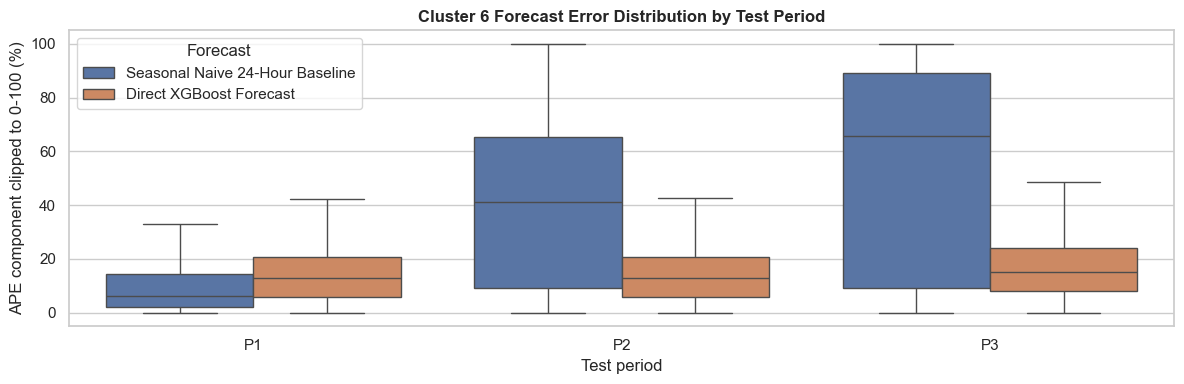

In [3]:
# ============================================
# 2) C6 APE boxplot by period
# ============================================
c6_box_df = art_c6.ape_box_df.copy()
c6_box_df["method"] = c6_box_df["method_display"]

output_dir = OUTPUT_DIR
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 4))
sns.boxplot(
    data=c6_box_df,
    x="period",
    y="APE_PCT_0_100",
    hue="method",
    showfliers=False,
)
plt.title("Cluster 6 Forecast Error Distribution by Test Period")
plt.ylabel("APE component clipped to 0-100 (%)")
plt.xlabel("Test period")
plt.legend(title="Forecast")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "c6_error_boxplot_by_period.svg", format="svg", bbox_inches="tight")
plt.show()


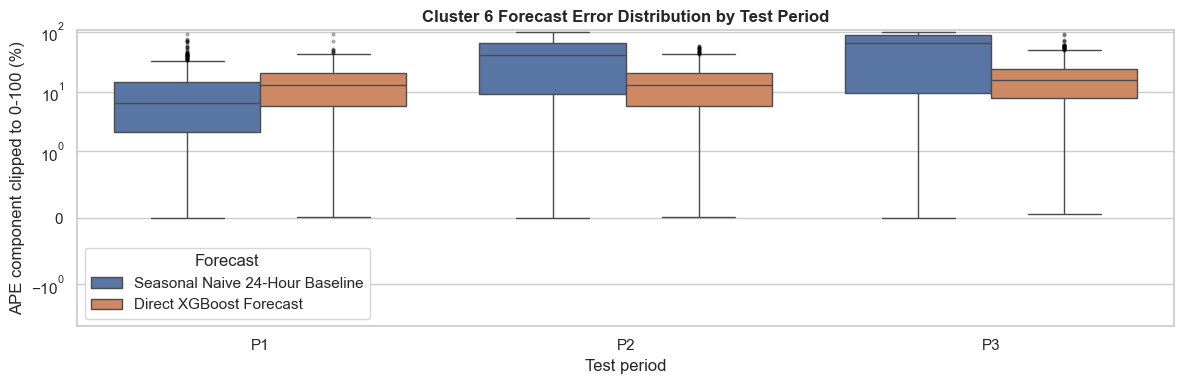

In [4]:
from pathlib import Path

c6_box_df = art_c6.ape_box_df.copy()
c6_box_df["method"] = c6_box_df["method_display"]

c6_box_df["APE_PCT_0_100"] = pd.to_numeric(c6_box_df["APE_PCT_0_100"], errors="coerce")
c6_box_df = c6_box_df.dropna(subset=["APE_PCT_0_100"])

output_dir = OUTPUT_DIR
output_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(
    data=c6_box_df,
    x="period",
    y="APE_PCT_0_100",
    hue="method",
    showfliers=True,
    flierprops={
        "marker": "o",
        "markersize": 2.0,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "alpha": 0.25,
    },
    ax=ax,
)

# symlog keeps the main distribution readable while retaining large APE outliers.
ax.set_yscale("symlog", linthresh=1)

ax.set_title("Cluster 6 Forecast Error Distribution by Test Period")
ax.set_ylabel("APE component clipped to 0-100 (%)")
ax.set_xlabel("Test period")
ax.legend(title="Forecast")

fig.tight_layout()
fig.savefig(
    output_dir / "c6_error_boxplot_by_period_symlog.svg",
    format="svg",
    bbox_inches="tight",
)
plt.show()


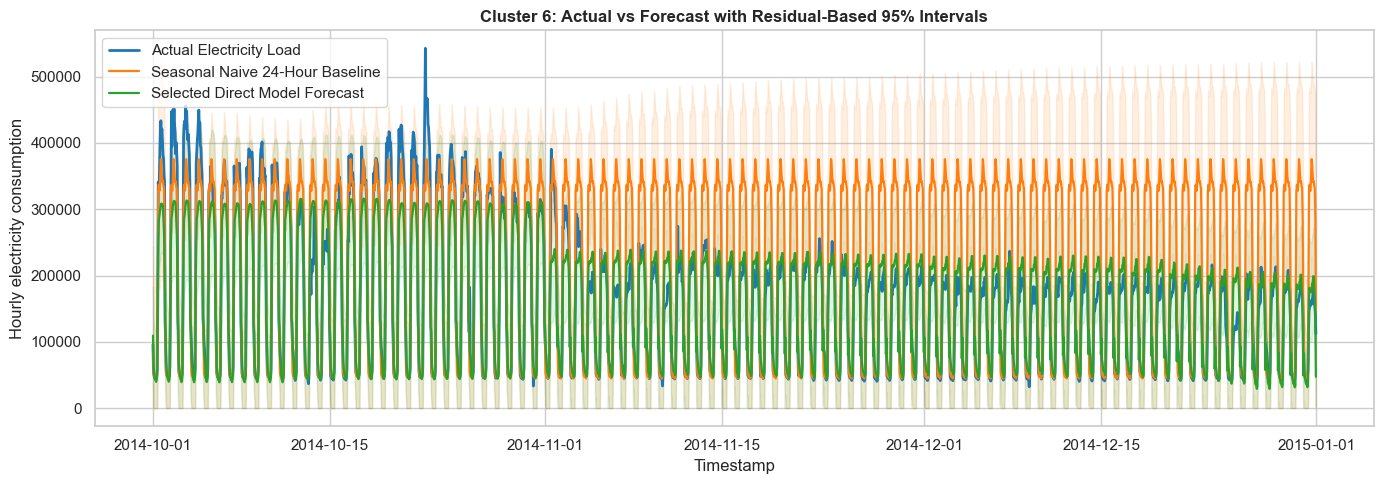

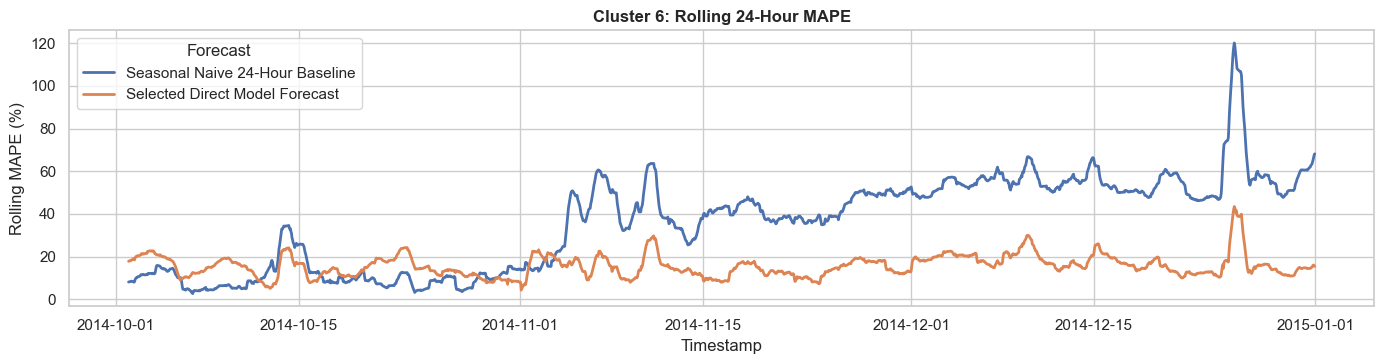

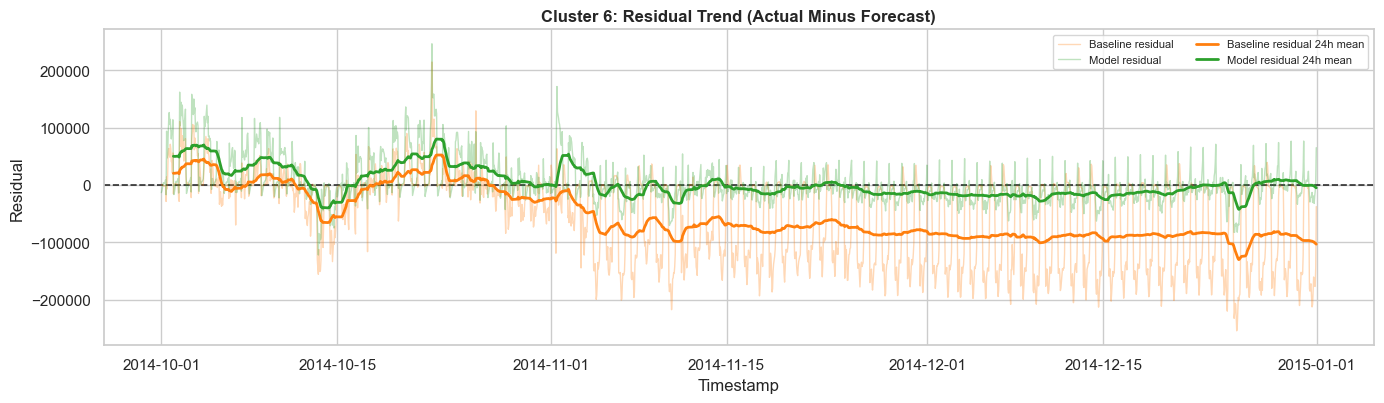

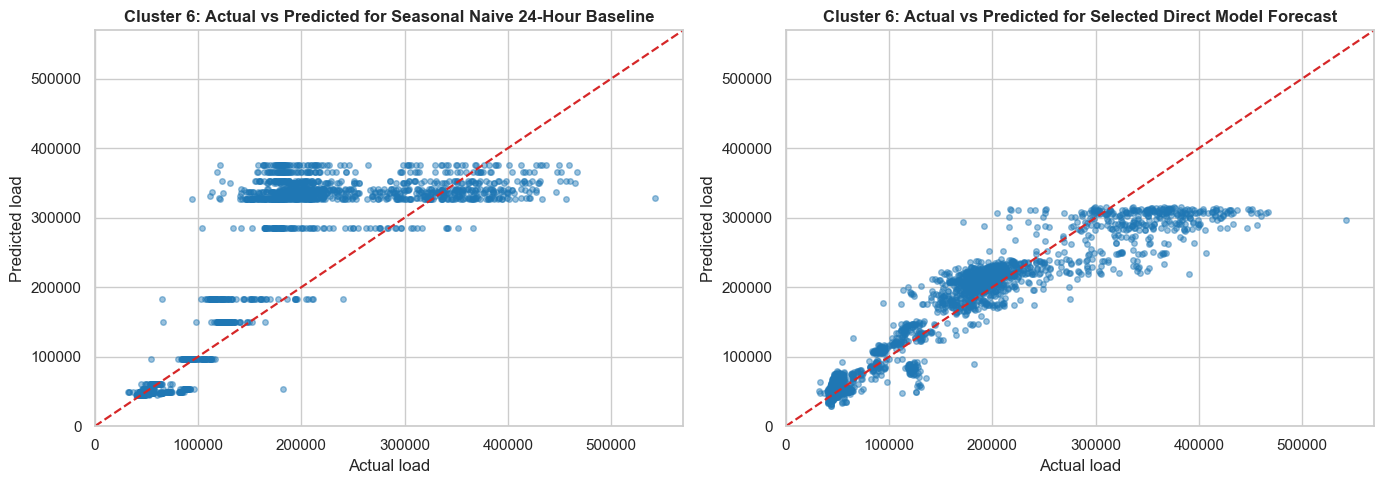

,method_display,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,legacy_MAPE_PCT,pred_nonzero_rate,actual_nonzero_rate
0,Seasonal Naive 24-Hour Baseline,34.726478,36.052627,39.123175,36.052627,1.0,1.0
1,Direct XGBoost Forecast,15.650182,15.650182,15.414158,15.650182,1.0,1.0


,method,period,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,n_obs,n_positive
0,Seasonal Naive 24-Hour Baseline,P1,10.456115,10.456115,11.663570,744,744
1,Seasonal Naive 24-Hour Baseline,P2,40.423050,40.803540,51.043495,720,720
2,Seasonal Naive 24-Hour Baseline,P3,53.484030,57.051480,72.982024,744,744
3,Direct XGBoost Forecast,P1,14.253793,14.253793,16.583562,744,744
4,Direct XGBoost Forecast,P2,14.804847,14.804847,13.216191,720,720
5,Direct XGBoost Forecast,P3,17.864636,17.864636,15.857767,744,744


,method,mean_signed_pct_error,median_ape_pct
0,Seasonal Naive 24-Hour Baseline,-30.564073,16.498635
1,Direct XGBoost Forecast,-3.923920,13.895640


,actual_mean,baseline_pred_mean,model_pred_mean,actual_std,baseline_pred_std,model_pred_std
0,164159.737319,217804.166667,160983.457168,107169.139933,135528.453553,90211.219196


In [5]:
# ============================================
# 3) c1c3-style standard diagnostics for C6
# ============================================
c6_results = run_cluster_analysis(
    art=art_c6,
    cluster_tag="c6",
    cluster_label="Cluster 6",
    baseline_col="pred_seasonal_naive",
    model_col="pred_selected_model",
    baseline_name="Seasonal Naive 24-Hour Baseline",
    model_name=method_display(selected_model),
    actual_name="Actual Electricity Load",
    target_label="Hourly electricity consumption",
    rolling_metric="mape",
    rolling_window=24,
    eps=MAPE_EPSILON,
    n_periods=N_PERIODS,
    save_svg=True,
    output_dir=str(OUTPUT_DIR),
)

display(c6_results["metric_table"][[
    "method_display",
    "MAPE_0_100",
    "EPSILON_MAPE_PCT",
    "WMAPE_0_100",
    "legacy_MAPE_PCT",
    "pred_nonzero_rate",
    "actual_nonzero_rate",
]])
display(c6_results["metrics_by_period"])
display(c6_results["error_decomposition"])
display(c6_results["distribution_shift_stats"])
